# H&M Fashion Recommender — Image & Text Search

Builds a FAISS index over the FashionCLIP image embeddings and implements two search modes:
- **Image search** — upload a photo, retrieve visually similar products.
- **Text search** — type a description, retrieve matching products.

Both query the *same* image index. This works because CLIP places images and text in a shared embedding space, so a text vector can be matched directly against image vectors.

Steps: Setup → Load Model → Load Embeddings → Build Index → Image Search → Text Search

## 1. Setup

Mount Drive, install FAISS, and load FashionCLIP.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q faiss-gpu-cu12 transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 5.9 MB/s eta 0:00:00


In [ ]:
import sys, os
sys.path.append('/content/drive/MyDrive/hm_fashion_project/src')
import faiss, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from paths import BASE_PROCESS, IMAGE_PATH


device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip").to(device)
processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model.eval()
print("loaded on", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

loaded on cpu


## 2. Load Article Metadata & Embeddings

Loads the article table and the precomputed FashionCLIP embeddings (71,664 × 512). Row order in `df_final` matches the embedding row order, so a FAISS result index maps directly back to an article.

In [ ]:
df_final = pd.read_parquet(os.path.join(BASE_PROCESS, "articles/articles_with_images.parquet"))
df_final['article_id'] = df_final['article_id'].astype(str).str.zfill(10)

fclip = np.load(os.path.join(BASE_PROCESS, "embeddings/fclip_image_embeddings.npy")).astype('float32')
print(df_final.shape, fclip.shape)

(71664, 12) (71664, 512)


## 3. Build the FAISS Index

`IndexFlatIP` performs exact inner-product search. Since the embeddings are L2-normalized, inner product equals cosine similarity.

In [ ]:
index = faiss.IndexFlatIP(512)
index.add(fclip)
print("index ready", index.ntotal)

index ready 71664


## 4. Image Search

Encode an uploaded image with FashionCLIP (vision model + visual projection, normalized) and retrieve its nearest neighbors from the index.

In [ ]:
def encode_image(path):
    img = Image.open(path).convert("RGB")
    inp = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.vision_model(pixel_values=inp['pixel_values'])
        feat = model.visual_projection(out.pooler_output)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype('float32')

def search(path, k=12):
    q = encode_image(path)
    distances, indices = index.search(q, k)
    return list(zip(indices[0], distances[0]))

### Optional: Convert AVIF to JPG

Some images come as AVIF, which PIL can't read by default. This converts a query image to JPG before searching.

In [ ]:
!pip install -q pillow-avif-plugin
from PIL import Image
import pillow_avif

img = Image.open("/content/eda7c6c301ea1bf99c82f0c6f996d3298599e69b.avif").convert("RGB")
jpg_path = "/content/img.jpg"
img.save(jpg_path, "JPEG")
print("converted")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 25.0 MB/s eta 0:00:00
converted


### Run Image Search

Search with a query image and display the top results with their similarity scores.

scores: [0.811, 0.796, 0.796, 0.787, 0.784, 0.783, 0.78, 0.78, 0.778, 0.777, 0.776, 0.774]


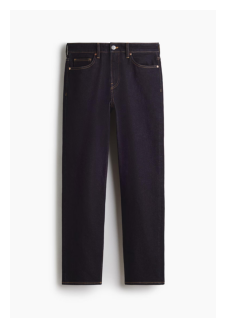

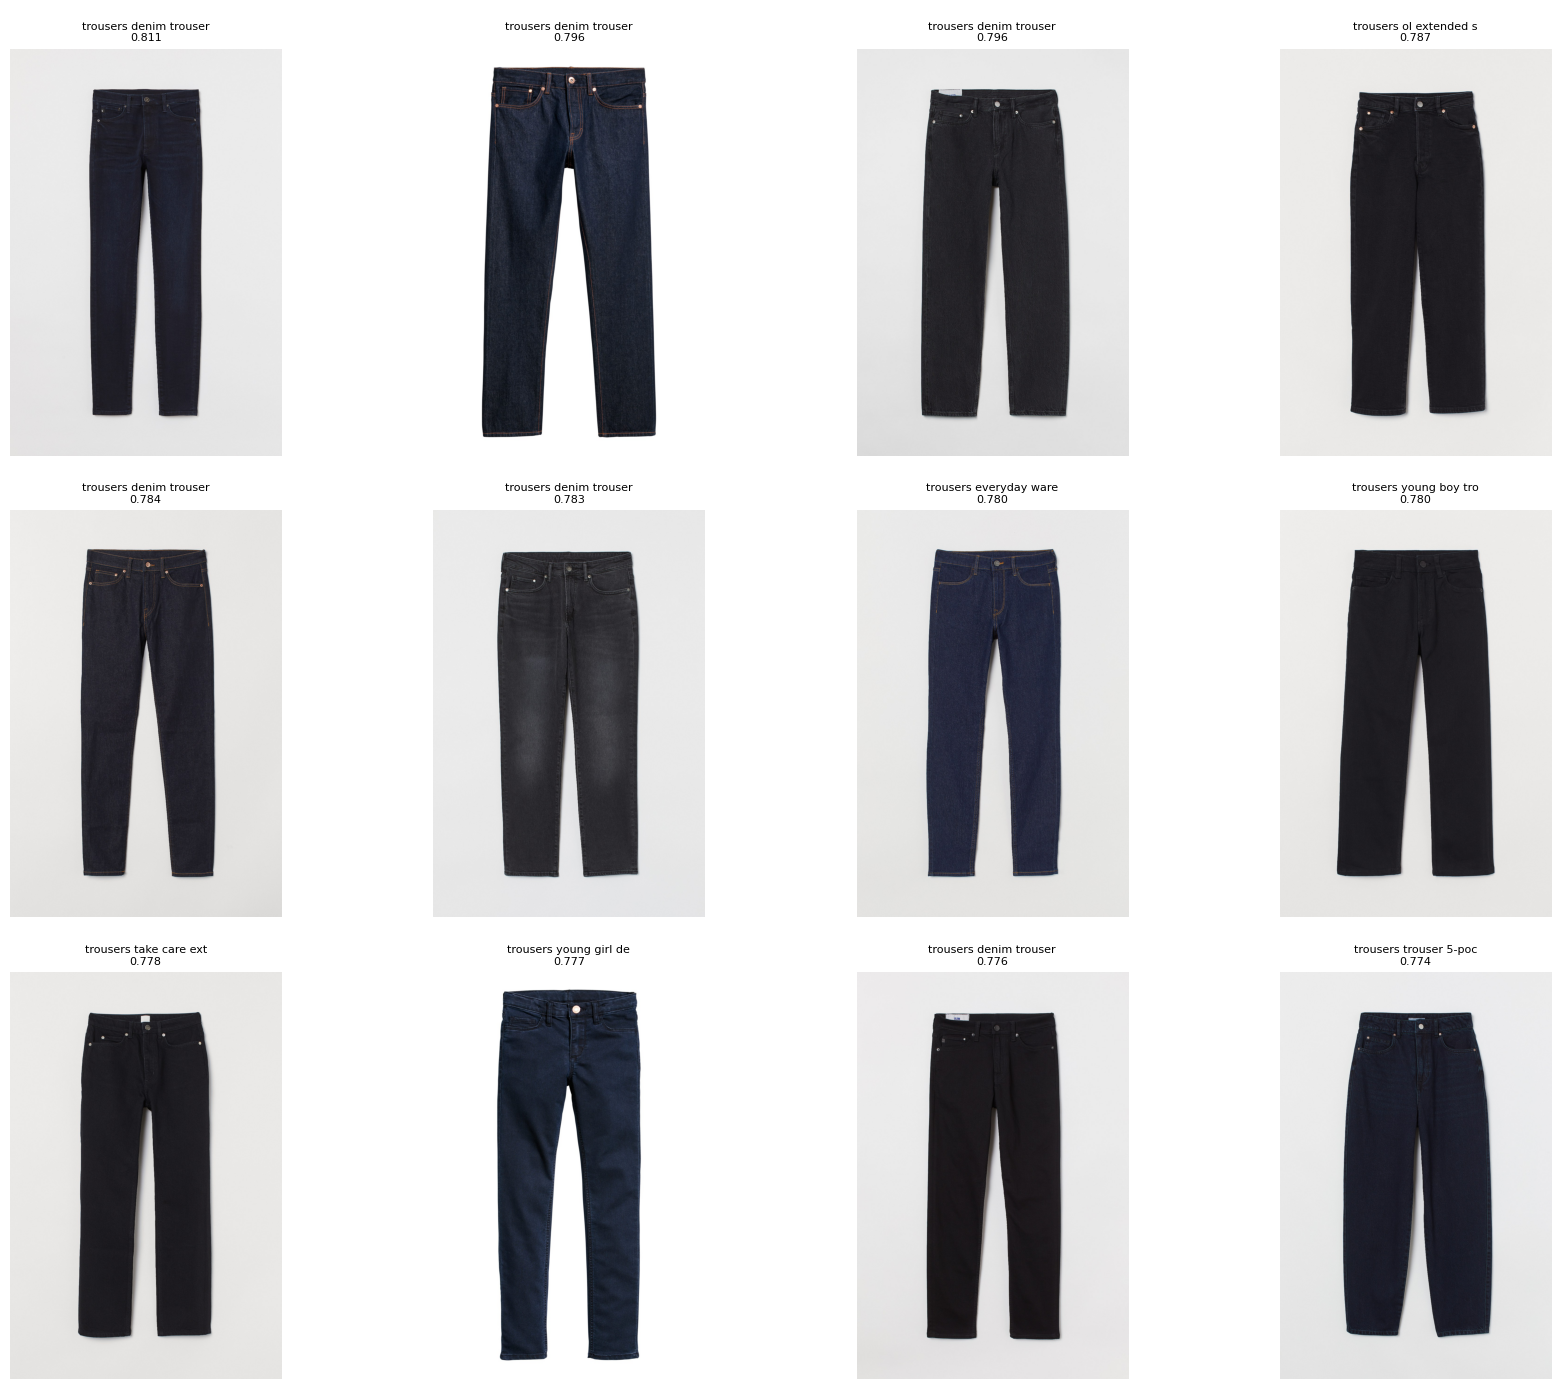

In [ ]:

results = search(jpg_path, k=12)
print("scores:", [round(float(d),3) for _, d in results])

plt.figure(figsize=(4,4)); plt.imshow(Image.open(jpg_path)); plt.axis('off'); plt.show()
fig, axes = plt.subplots(3, 4, figsize=(18,14))
for ax, (idx, dist) in zip(axes.flatten(), results):
    row = df_final.iloc[idx]; aid = row['article_id']
    try: ax.imshow(Image.open(os.path.join(IMAGE_PATH, aid[:3], f"{aid}.jpg")))
    except: pass
    ax.set_title(f"{row['clean_category'] if 'clean_category' in row else ''}\n{row['article_metadata'][:22]}\n{dist:.3f}", fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Text Search

Encode a text query with FashionCLIP's text encoder and search the *same* image index. A query like "black oversized t-shirt" lands near matching product images in the shared CLIP space.

In [ ]:
def encode_text_query(text):
    inp = processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = model.text_model(input_ids=inp['input_ids'], attention_mask=inp['attention_mask'])
        feat = model.text_projection(out.pooler_output)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype('float32')

def text_search(query, k=12):
    q = encode_text_query(query)
    distances, indices = index.search(q, k)   # same image index!
    return list(zip(indices[0], distances[0]))

### Run Text Search

Search with a typed query and display the matching products.

query: sundress
scores: [0.351, 0.348, 0.345, 0.345, 0.343, 0.342, 0.341, 0.341, 0.341, 0.341, 0.341, 0.34]


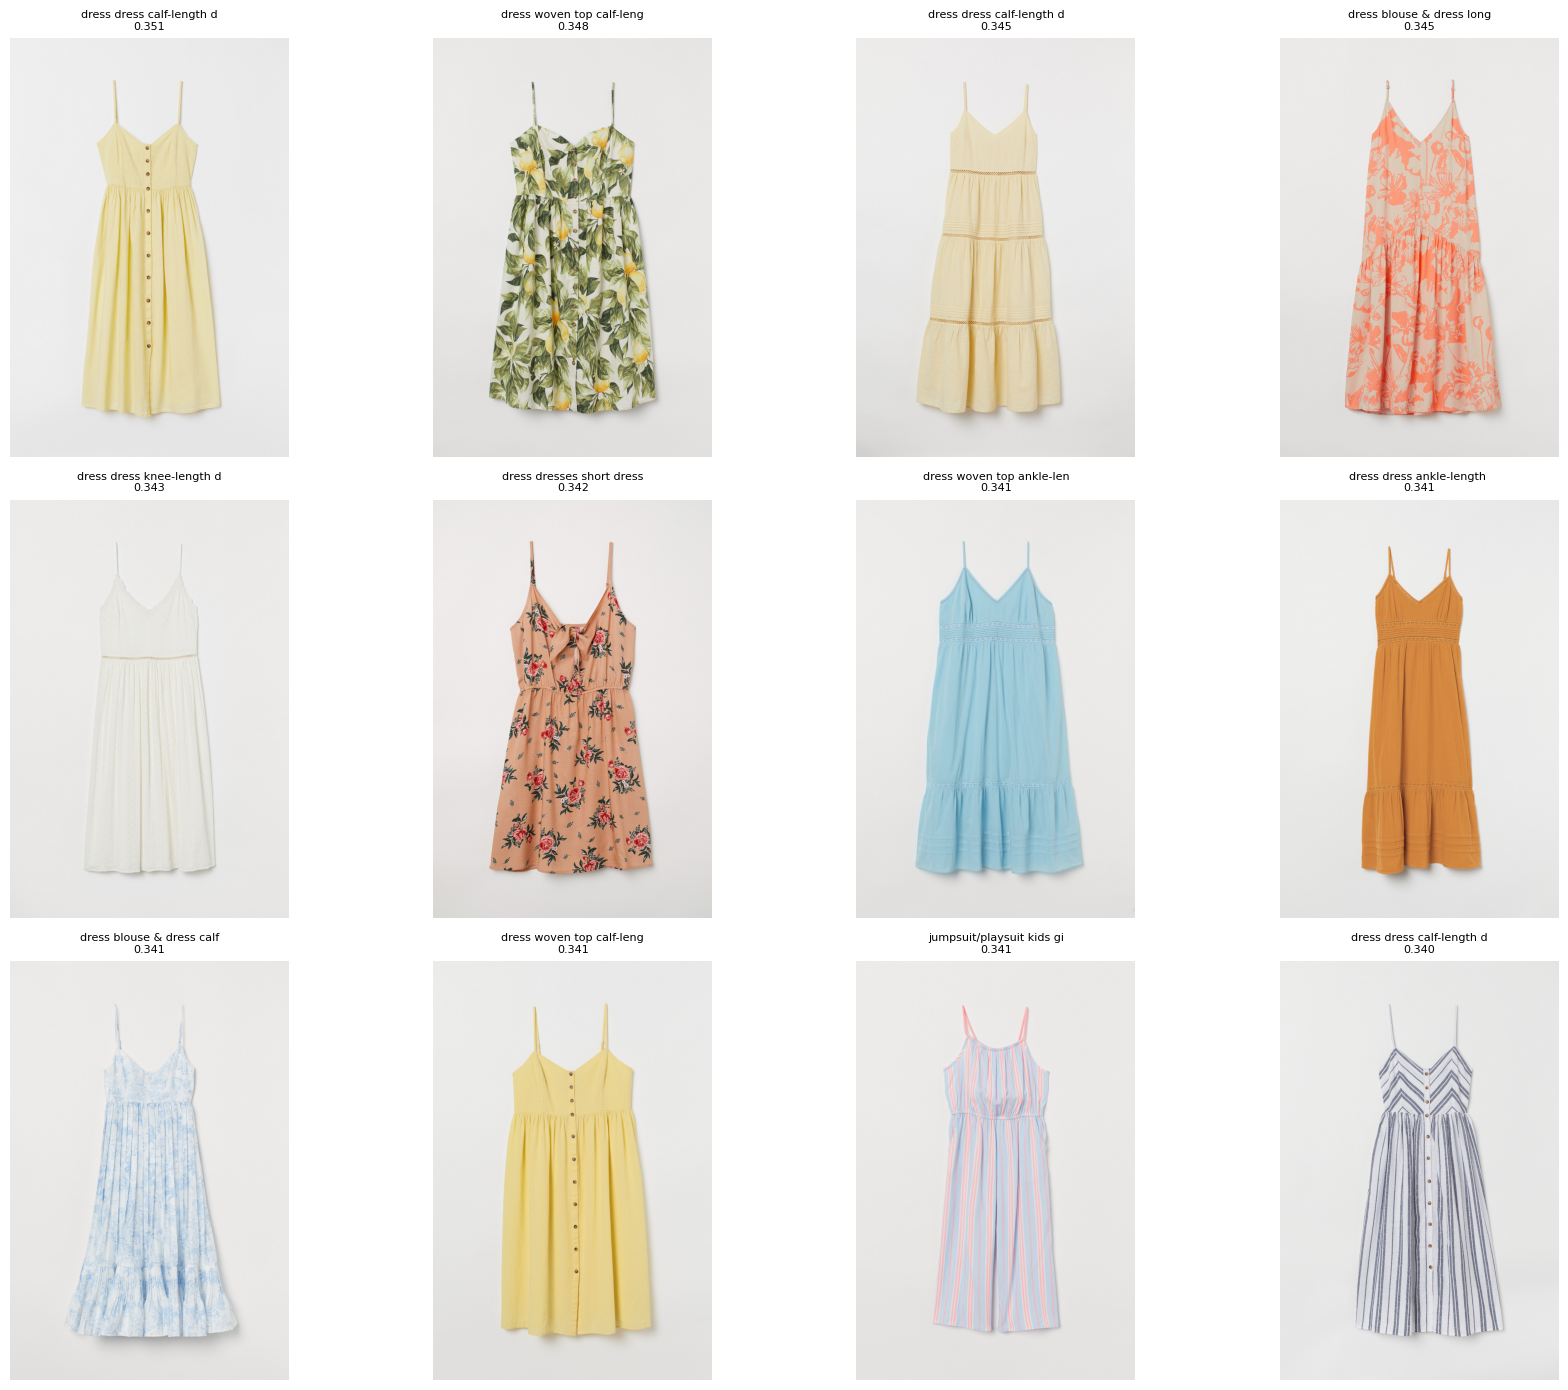

In [ ]:
query = "sundress"
results = text_search(query, k=12)
print("query:", query)
print("scores:", [round(float(d),3) for _, d in results])

fig, axes = plt.subplots(3, 4, figsize=(18,14))
for ax, (idx, dist) in zip(axes.flatten(), results):
    row = df_final.iloc[idx]; aid = row['article_id']
    try: ax.imshow(Image.open(os.path.join(IMAGE_PATH, aid[:3], f"{aid}.jpg")))
    except: pass
    ax.set_title(f"{row['article_metadata'][:25]}\n{dist:.3f}", fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()